# Task 3 — Customer Churn Prediction

**CodSoft ML Internship**

Predict which bank customers will leave (`Exited = 1`) from their account and demographic profile.

- **Dataset:** [Churn Modelling](https://www.kaggle.com/datasets/shivan118/churn-modeling-dataset) — 10,000 retail-bank customers in France, Spain and Germany.
- **Approach:** `ColumnTransformer` preprocessing → three classifiers compared → gradient boosting.
- **Headline metric:** **ROC-AUC**, plus recall on the churn class. Not accuracy — only 20% of
  customers churn, so predicting "nobody leaves" is already ~80% accurate and useless.

The business question is not "how often is the model right?" It is **"of the customers who are
about to leave, how many can we find in time to do something about it?"** That is recall, and this
notebook is largely about what it costs.

In [1]:
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay,
                             average_precision_score, classification_report,
                             confusion_matrix, f1_score, precision_recall_curve,
                             precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 200)

---
## 1. Load and inspect

In [2]:
df = pd.read_csv("data/Churn_Modelling.csv")
print("shape:", df.shape)
print("missing values:", df.isna().sum().sum())
print("duplicate rows :", df.duplicated().sum())
df.head()

shape: (10000, 14)
missing values: 0
duplicate rows : 0


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


No missing values and no duplicate rows — unusually clean, which means the interesting work is in
the modelling rather than the cleaning.

### 1.1 Drop the identifier columns

Three columns must go before modelling:

| Column | Why it goes |
|---|---|
| `RowNumber` | Just the row index. Any signal here would mean the file is sorted by outcome — a leak, not a feature. |
| `CustomerId` | A random account number. 10,000 unique values, no meaning. |
| `Surname` | 2,932 unique values. This is the dangerous one: a tree can split on a rare surname and "predict" a specific individual it memorised in training. It would raise the training score and generalise to nothing. |

`Surname` is the one worth pausing on. It is tempting to treat it as a categorical feature — it is
not, it is an identifier wearing a categorical costume.

In [3]:
print("unique values in the identifier columns:")
print(df[["RowNumber", "CustomerId", "Surname"]].nunique().to_string())

df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])
print(f"\nremaining columns ({df.shape[1]}):", list(df.columns))

unique values in the identifier columns:
RowNumber     10000
CustomerId    10000
Surname        2932

remaining columns (11): ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


---
## 2. The target: how imbalanced is it?

Exited
stayed     7963
churned    2037

churn rate: 20.37%
accuracy of a 'nobody churns' baseline: 79.63%


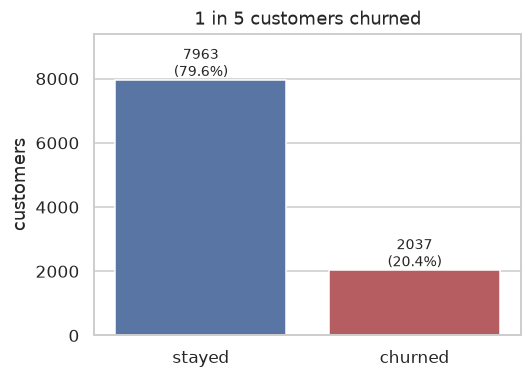

In [4]:
churn_rate = df["Exited"].mean()
print(df["Exited"].value_counts().rename({0: "stayed", 1: "churned"}).to_string())
print(f"\nchurn rate: {churn_rate:.2%}")
print(f"accuracy of a 'nobody churns' baseline: {1 - churn_rate:.2%}")

fig, ax = plt.subplots(figsize=(5, 3.6))
counts = df["Exited"].value_counts().sort_index()
sns.barplot(x=["stayed", "churned"], y=counts.values, ax=ax,
            hue=["stayed", "churned"], palette=["#4c72b0", "#c44e52"], legend=False)
for i, v in enumerate(counts.values):
    ax.text(i, v + 120, f"{v}\n({v / len(df):.1%})", ha="center", fontsize=9)
ax.set(title="1 in 5 customers churned", ylabel="customers", xlabel="")
ax.set_ylim(0, counts.max() * 1.18)
fig.tight_layout()
fig.savefig("results/churn_balance.png", dpi=150, bbox_inches="tight")
plt.show()

**A model that predicts "nobody churns" is 79.6% accurate and worth nothing to the bank.** Every
accuracy figure below has to be read against that number.

---
## 3. Who actually churns?

Churn rate broken down by each candidate feature. The flat bars matter as much as the steep ones —
a flat bar is a feature carrying no signal.

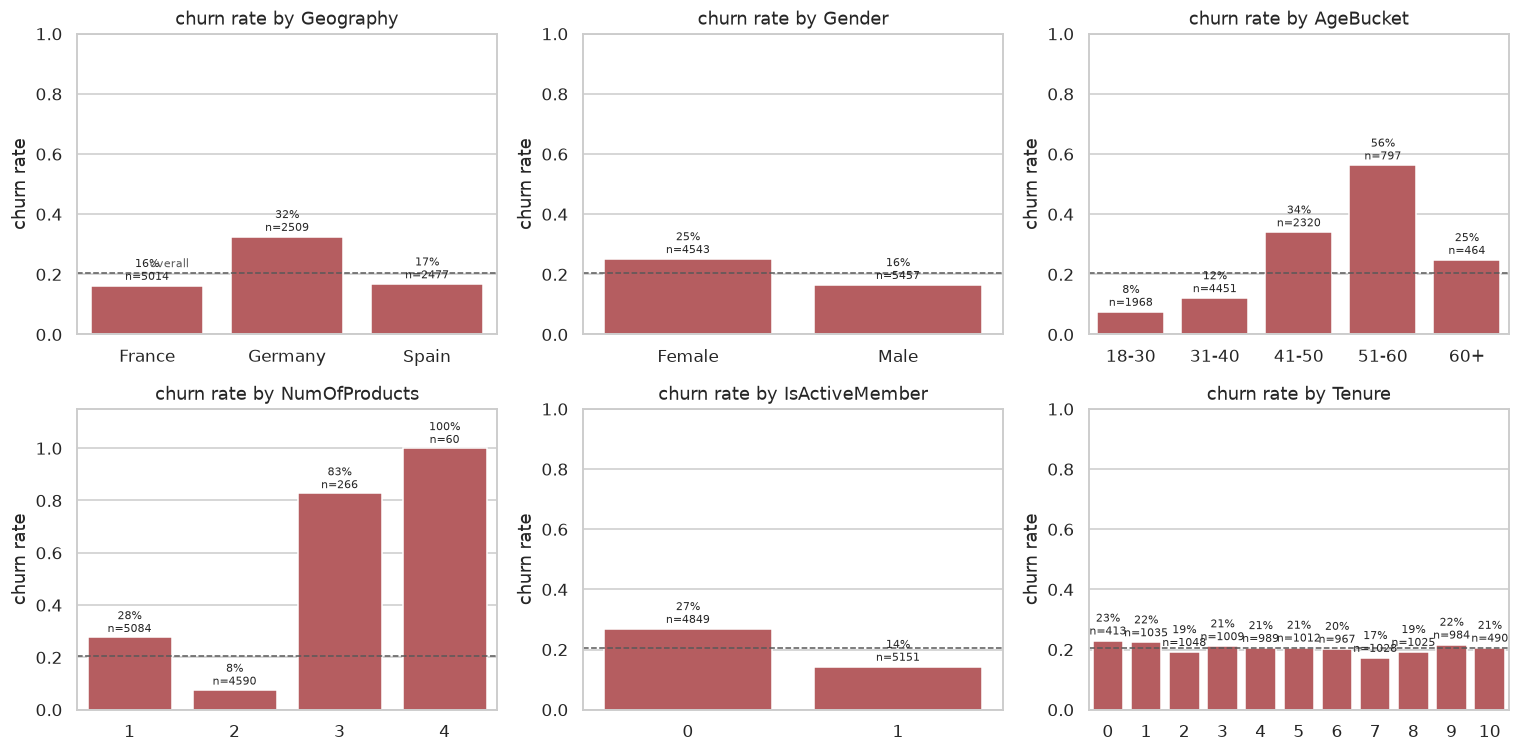

In [5]:
df["AgeBucket"] = pd.cut(df["Age"], [17, 30, 40, 50, 60, 100],
                         labels=["18-30", "31-40", "41-50", "51-60", "60+"])

breakdowns = ["Geography", "Gender", "AgeBucket", "NumOfProducts", "IsActiveMember", "Tenure"]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), breakdowns):
    rate = df.groupby(col, observed=True)["Exited"].agg(["mean", "count"])
    sns.barplot(x=rate.index.astype(str), y=rate["mean"], ax=ax, color="#c44e52")
    ax.axhline(churn_rate, ls="--", c="0.35", lw=1)
    ax.set(title=f"churn rate by {col}", ylabel="churn rate", xlabel="",
           ylim=(0, max(1.0, rate["mean"].max() * 1.15)))
    for i, (m, n) in enumerate(zip(rate["mean"], rate["count"])):
        ax.text(i, m + 0.02, f"{m:.0%}\nn={n}", ha="center", fontsize=7)
axes.ravel()[0].text(0.02, churn_rate + 0.02, "overall", fontsize=7, color="0.35")
fig.tight_layout()
fig.savefig("results/churn_by_feature.png", dpi=150, bbox_inches="tight")
plt.show()

### What the breakdowns say

**`NumOfProducts` is the strongest signal, and it is not monotonic.** Churn falls from 28% (one
product) to 7.6% (two products) — the usual cross-selling story — and then *inverts*: 83% at three
products and **100% at four**. Whatever is happening to customers with 3–4 products, they all leave.

This single fact decides the modelling. A linear model can fit "more products → less churn" or the
reverse, but not both at once. A tree can split `NumOfProducts <= 2` and handle each side separately.
That is the main reason the tree models beat logistic regression below.

*A caveat on the 100%:* it is 60 customers. Real, but a thin base — a genuinely careful analysis
would flag it to the business rather than trust it as a stable rate.

**Age is the second strongest.** Churn climbs steadily to 56% for 51–60 year olds, then *drops* for
60+ — another non-monotonic relationship.

**Germany churns at double the rate of France or Spain** (32% vs ~16%), despite Spain and France
being nearly identical. That is worth a business question, not just a feature.

**Inactive members churn at ~27% versus ~14% for active ones** — the clearest actionable lever here.

**`Tenure` is flat.** Every bar sits on the overall rate. Length of relationship carries essentially
no information about leaving, which is a genuinely surprising negative result.

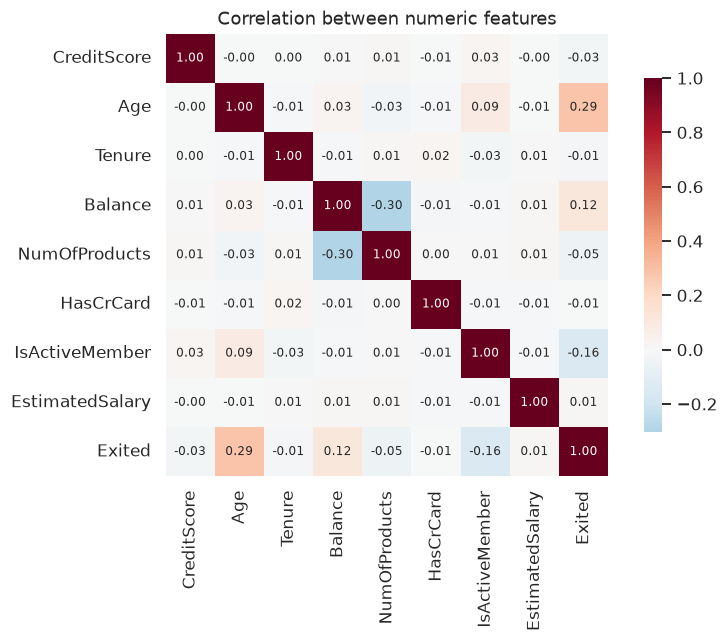

linear correlation with Exited, strongest first:
Age                0.285
IsActiveMember     0.156
Balance            0.119
NumOfProducts      0.048
CreditScore        0.027
Tenure             0.014
EstimatedSalary    0.012
HasCrCard          0.007


In [6]:
numeric = df.select_dtypes(include=np.number)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(numeric.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, ax=ax, cbar_kws={"shrink": 0.8}, annot_kws={"size": 8})
ax.set_title("Correlation between numeric features")
fig.tight_layout()
fig.savefig("results/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("linear correlation with Exited, strongest first:")
print(numeric.corr()["Exited"].drop("Exited").abs().sort_values(ascending=False).round(3).to_string())

No feature pair is strongly correlated, so there is no redundancy to remove. But notice how *weak*
every linear correlation with `Exited` is — the strongest is Age at 0.29, and `NumOfProducts`, which
the breakdown above showed is the most informative feature in the dataset, has a correlation near
zero.

That is the non-monotonicity showing up as a number: **Pearson correlation measures straight lines,
and this relationship is a V.** Judging features by their correlation with the target would have
thrown away the best one.

---
## 4. Preprocessing

A `ColumnTransformer` keeps the categorical and numeric paths separate and, crucially, lives
*inside* the pipeline — so the scaler is fitted on training folds only and never sees the test set.

- **One-hot** `Geography` and `Gender`. `drop="first"` avoids the redundant collinear column.
- **StandardScaler** on the numeric columns. Logistic regression needs it (`Balance` spans 0–250,000
  while `NumOfProducts` spans 1–4, and without scaling the penalty term is meaningless). Trees do not
  need it, but it does them no harm, so one shared preprocessor serves all three models.

In [7]:
X = df.drop(columns=["Exited", "AgeBucket"])
y = df["Exited"]

categorical = ["Geography", "Gender"]
numeric_cols = [c for c in X.columns if c not in categorical]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical),
    ("num", StandardScaler(), numeric_cols),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print(f"categorical: {categorical}")
print(f"numeric    : {numeric_cols}")
print(f"\ntrain: {X_train.shape[0]} customers ({y_train.mean():.2%} churn)")
print(f"test : {X_test.shape[0]} customers ({y_test.mean():.2%} churn, {y_test.sum()} churners)")

categorical: ['Geography', 'Gender']
numeric    : ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

train: 8000 customers (20.38% churn)
test : 2000 customers (20.35% churn, 407 churners)


---
## 5. Model comparison

Three algorithms, each with and without class balancing:

- **LogisticRegression** — linear baseline. Fast, interpretable coefficients.
- **RandomForest** — bagged trees, handles non-monotonic splits natively.
- **GradientBoosting** — boosted trees, each one correcting the previous ensemble's errors.

`GradientBoostingClassifier` has no `class_weight` parameter, so its balanced variant is fitted with
per-sample weights instead — the same idea delivered through a different argument.

In [8]:
def build(model):
    return Pipeline([("pre", preprocessor), ("clf", model)])

specs = [
    ("LogisticRegression", None,       LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ("LogisticRegression", "balanced", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE,
                                                          class_weight="balanced")),
    ("RandomForest",       None,       RandomForestClassifier(n_estimators=400, min_samples_leaf=2,
                                                              random_state=RANDOM_STATE, n_jobs=-1)),
    ("RandomForest",       "balanced", RandomForestClassifier(n_estimators=400, min_samples_leaf=2,
                                                              random_state=RANDOM_STATE, n_jobs=-1,
                                                              class_weight="balanced")),
    ("GradientBoosting",   None,       GradientBoostingClassifier(random_state=RANDOM_STATE)),
    ("GradientBoosting",   "balanced", GradientBoostingClassifier(random_state=RANDOM_STATE)),
]

fitted, rows = {}, []
for name, weight, model in specs:
    pipe = build(model)
    if name == "GradientBoosting" and weight == "balanced":
        pipe.fit(X_train, y_train,
                 clf__sample_weight=compute_sample_weight("balanced", y_train))
    else:
        pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    key = f"{name} ({weight or 'default'})"
    fitted[key] = pipe
    rows.append({
        "model": name, "class weights": weight or "default",
        "accuracy": (pred == y_test).mean(),
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba),
        "PR-AUC": average_precision_score(y_test, proba),
    })

comparison = pd.DataFrame(rows).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
comparison.style.format({c: "{:.4f}" for c in
                         ["accuracy", "precision", "recall", "F1", "ROC-AUC", "PR-AUC"]}) \
          .background_gradient(subset=["ROC-AUC"], cmap="Greens")

,model,class weights,accuracy,precision,recall,F1,ROC-AUC,PR-AUC
0,GradientBoosting,default,0.8700,0.7928,0.4889,0.6049,0.8711,0.7217
1,GradientBoosting,balanced,0.8000,0.5057,0.7592,0.6071,0.8690,0.7135
2,RandomForest,balanced,0.8375,0.5919,0.6486,0.6190,0.8587,0.6908
3,RandomForest,default,0.8680,0.7967,0.4717,0.5926,0.8586,0.6973
4,LogisticRegression,balanced,0.7140,0.3878,0.7002,0.4991,0.7772,0.4679
5,LogisticRegression,default,0.8080,0.5891,0.1867,0.2836,0.7748,0.4790


### Reading the table

**Gradient boosting wins on ROC-AUC**, with random forest close behind and logistic regression a
long way back. That gap is the non-monotonic `NumOfProducts` and `Age` relationships from §3 — the
linear model literally cannot represent them, and no amount of scaling or regularisation fixes that.

**Logistic regression's default-weight recall is 0.19.** It finds fewer than one churner in five. Its
accuracy (0.81) is barely above the do-nothing baseline (0.80), which is exactly the trap accuracy
sets on imbalanced data.

Now look at what class balancing does to gradient boosting:

| | accuracy | precision | recall | ROC-AUC |
|---|---|---|---|---|
| default weights | 0.870 | 0.793 | 0.489 | 0.871 |
| balanced weights | 0.800 | 0.506 | 0.759 | 0.869 |

Recall jumps from 49% to 76%. Accuracy falls by 7 points. **And ROC-AUC is unchanged.**

---
## 6. The key insight: balancing does not improve the model

ROC-AUC measures how well a model *ranks* customers by risk. It is threshold-independent. The fact
that it barely moves (0.871 → 0.869) means the balanced model is not better at telling churners from
non-churners — **it is the same model reporting at a different operating point.**

`class_weight="balanced"` is not a fix for imbalance. It is a threshold change wearing a disguise.

We can prove it: take the *default-weight* model, leave it exactly as it is, and simply lower the
0.5 cut-off until its recall matches the balanced model's.

In [9]:
gb_default = fitted["GradientBoosting (default)"]
gb_balanced = fitted["GradientBoosting (balanced)"]

proba_default = gb_default.predict_proba(X_test)[:, 1]
target_recall = recall_score(y_test, gb_balanced.predict(X_test))

# lowest threshold on the *default* model that reaches the balanced model's recall
grid = np.linspace(0.05, 0.95, 181)
recalls = np.array([recall_score(y_test, proba_default >= t) for t in grid])
matched = grid[recalls >= target_recall].max()
pred_matched = (proba_default >= matched).astype(int)

print(f"balanced model            : recall {target_recall:.4f}  "
      f"precision {precision_score(y_test, gb_balanced.predict(X_test)):.4f}  "
      f"F1 {f1_score(y_test, gb_balanced.predict(X_test)):.4f}")
print(f"default model @ thr {matched:.3f} : recall {recall_score(y_test, pred_matched):.4f}  "
      f"precision {precision_score(y_test, pred_matched):.4f}  "
      f"F1 {f1_score(y_test, pred_matched):.4f}")
print("\nSame model, same ranking — only the cut-off moved.")

balanced model            : recall 0.7592  precision 0.5057  F1 0.6071
default model @ thr 0.210 : recall 0.7641  precision 0.5353  F1 0.6296

Same model, same ranking — only the cut-off moved.


Same recall — and the threshold-tuned default model gets there with **better precision and better
F1** than the balanced model does. Class weighting did not just fail to help, it reached the same
operating point slightly less efficiently.

**Why this matters:** it reframes the decision. The question is not "which class weighting should I
use?" but **"where on the precision/recall curve does the bank want to sit?"** — and that is a
business question with a numeric answer, not a hyperparameter. So the model we ship uses default
weights and an explicit, chosen threshold.

### 6.1 ROC and precision–recall curves

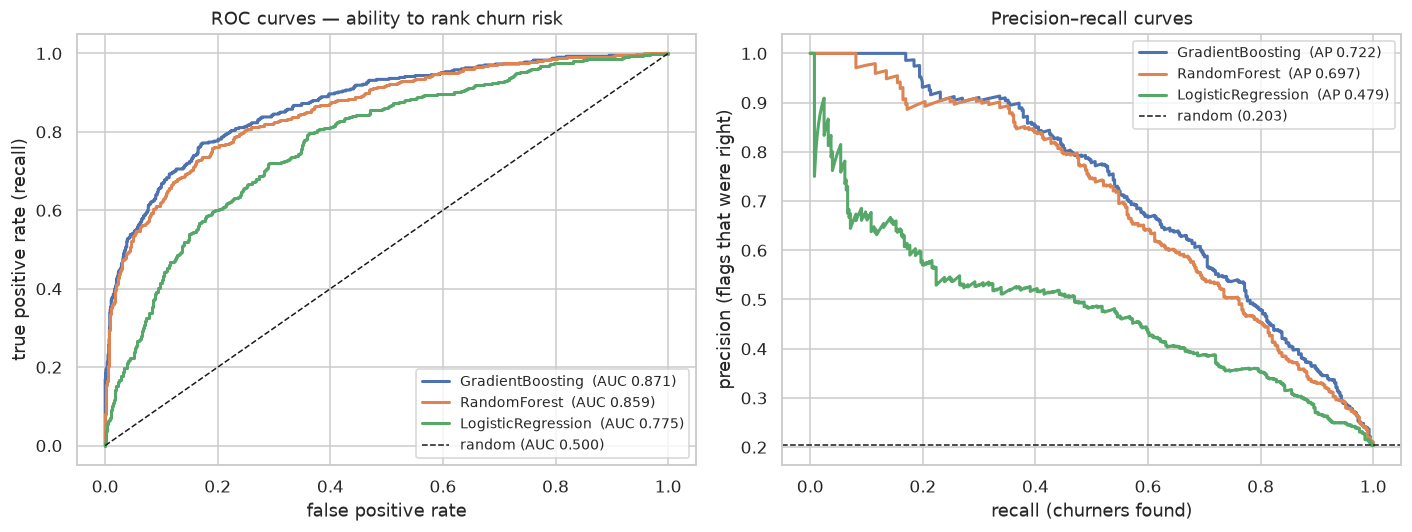

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for key in ["GradientBoosting (default)", "RandomForest (default)", "LogisticRegression (default)"]:
    proba = fitted[key].predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, lw=2,
                 label=f"{key.split(' (')[0]}  (AUC {roc_auc_score(y_test, proba):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="random (AUC 0.500)")
axes[0].set(xlabel="false positive rate", ylabel="true positive rate (recall)",
            title="ROC curves — ability to rank churn risk")
axes[0].legend(loc="lower right", fontsize=9)

for key in ["GradientBoosting (default)", "RandomForest (default)", "LogisticRegression (default)"]:
    proba = fitted[key].predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, lw=2,
                 label=f"{key.split(' (')[0]}  (AP {average_precision_score(y_test, proba):.3f})")
axes[1].axhline(y_test.mean(), ls="--", c="k", lw=1,
                label=f"random ({y_test.mean():.3f})")
axes[1].set(xlabel="recall (churners found)", ylabel="precision (flags that were right)",
            title="Precision–recall curves")
axes[1].legend(loc="upper right", fontsize=9)

fig.tight_layout()
fig.savefig("results/roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

The precision–recall curve on the right is the more honest picture on imbalanced data: the random
baseline for ROC is 0.5 regardless of imbalance, but for PR it is the churn rate itself (0.20), so
the improvement over doing nothing is visible rather than flattered.

### 6.2 Choosing an operating point

If retention costs the bank a fixed amount per contacted customer and saving a churner is worth
some multiple of that, the best threshold follows from the ratio. Below: how precision, recall and
F1 move as the cut-off slides.

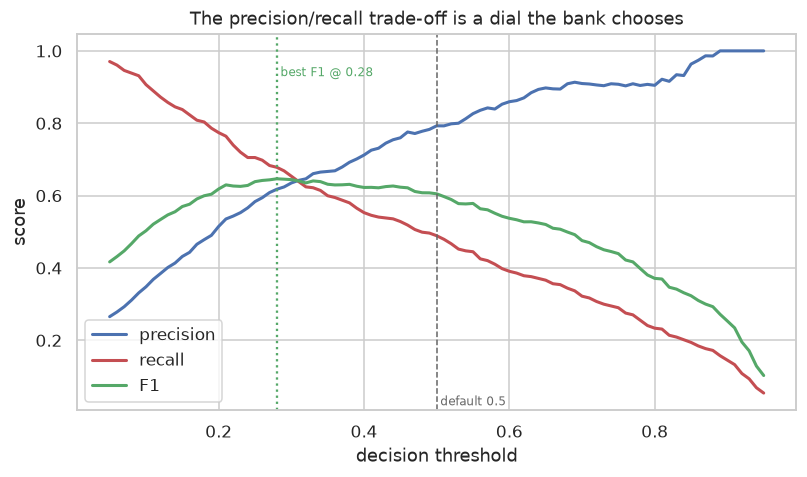

default threshold 0.50 -> precision 0.793, recall 0.489
best-F1 threshold 0.28 -> precision 0.617, recall 0.678, F1 0.646


In [11]:
thresholds = np.linspace(0.05, 0.95, 91)
curve = pd.DataFrame({
    "threshold": thresholds,
    "precision": [precision_score(y_test, proba_default >= t, zero_division=0) for t in thresholds],
    "recall":    [recall_score(y_test, proba_default >= t) for t in thresholds],
    "F1":        [f1_score(y_test, proba_default >= t) for t in thresholds],
})
best_f1 = curve.loc[curve["F1"].idxmax()]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for col, c in [("precision", "#4c72b0"), ("recall", "#c44e52"), ("F1", "#55a868")]:
    ax.plot(curve["threshold"], curve[col], label=col, lw=2, color=c)
ax.axvline(0.5, ls="--", c="0.4", lw=1)
ax.text(0.505, 0.02, "default 0.5", fontsize=8, color="0.4")
ax.axvline(best_f1["threshold"], ls=":", c="#55a868", lw=1.5)
ax.text(best_f1["threshold"] + 0.005, 0.93, f"best F1 @ {best_f1['threshold']:.2f}",
        fontsize=8, color="#55a868")
ax.set(xlabel="decision threshold", ylabel="score",
       title="The precision/recall trade-off is a dial the bank chooses")
ax.legend()
fig.tight_layout()
fig.savefig("results/threshold_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"default threshold 0.50 -> precision {curve.loc[curve.threshold.sub(0.5).abs().idxmin(), 'precision']:.3f}, "
      f"recall {curve.loc[curve.threshold.sub(0.5).abs().idxmin(), 'recall']:.3f}")
print(f"best-F1 threshold {best_f1['threshold']:.2f} -> precision {best_f1['precision']:.3f}, "
      f"recall {best_f1['recall']:.3f}, F1 {best_f1['F1']:.3f}")

---
## 7. The chosen model

**`GradientBoostingClassifier` with default class weights, reporting at a threshold of
`best_f1["threshold"]` instead of 0.5.**

Section 6 showed the weighting made no difference to the ranking, so the only real decision left is
where to cut. We move the cut-off *below* 0.5 because the two errors are not equally expensive:

- A **false positive** costs one retention offer sent to someone who was staying anyway.
- A **false negative** costs the entire customer relationship, silently.

With no cost figures supplied, we take the threshold that maximises F1 — a defensible neutral
choice. Given real numbers (cost of an offer, lifetime value of a saved customer) you would read
the operating point straight off the curve in §6.2 instead, and the shipped model stores the
threshold precisely so it can be changed without retraining.

decision threshold: 0.28  (sklearn's default would be 0.50)

              precision    recall  f1-score   support

      stayed     0.9156    0.8927    0.9040      1593
     churned     0.6174    0.6781    0.6464       407

    accuracy                         0.8490      2000
   macro avg     0.7665    0.7854    0.7752      2000
weighted avg     0.8550    0.8490    0.8516      2000

ROC-AUC: 0.8711   (threshold-independent — unchanged by the choice above)

for comparison, at the default 0.50 threshold: recall 0.4889, F1 0.6049


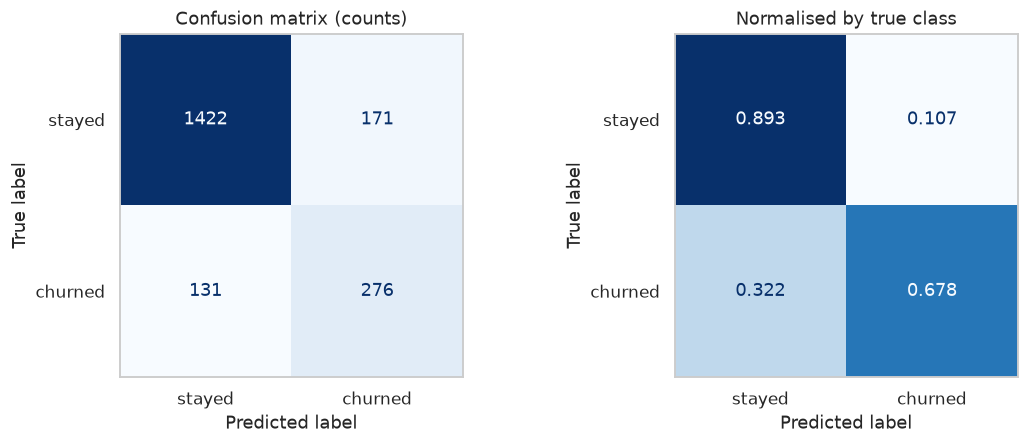


caught   276 of 407 churners (67.8%)
missed   131 churners — the silent, expensive failure
contacted 171 customers who were staying anyway — the cheap failure


In [12]:
best_model = gb_default
THRESHOLD = float(best_f1["threshold"])

y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= THRESHOLD).astype(int)

print(f"decision threshold: {THRESHOLD:.2f}  (sklearn's default would be 0.50)\n")
print(classification_report(y_test, y_pred, target_names=["stayed", "churned"], digits=4))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}   "
      f"(threshold-independent — unchanged by the choice above)")

at_half = (y_proba >= 0.5).astype(int)
print(f"\nfor comparison, at the default 0.50 threshold: "
      f"recall {recall_score(y_test, at_half):.4f}, F1 {f1_score(y_test, at_half):.4f}")

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
ConfusionMatrixDisplay(cm, display_labels=["stayed", "churned"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
axes[0].set_title("Confusion matrix (counts)")
axes[0].grid(False)
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="true"),
                       display_labels=["stayed", "churned"]).plot(
    ax=axes[1], cmap="Blues", colorbar=False, values_format=".3f")
axes[1].set_title("Normalised by true class")
axes[1].grid(False)
fig.tight_layout()
fig.savefig("results/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\ncaught   {tp} of {tp + fn} churners ({tp / (tp + fn):.1%})")
print(f"missed   {fn} churners — the silent, expensive failure")
print(f"contacted {fp} customers who were staying anyway — the cheap failure")

### 7.1 What drives the prediction?

Two views, because the usual one is misleading on its own.

**Impurity importance** (left) counts how much each feature reduced impurity across the ensemble.
It is biased toward high-cardinality continuous features — `EstimatedSalary` can be split in
thousands of places, `Gender` in one — so a noise variable with many distinct values can outrank a
genuinely predictive binary one.

**Permutation importance** (right) shuffles one column in the *test* set and measures how much
ROC-AUC drops. It answers the question we actually care about: how much does the model's real
performance depend on this feature?

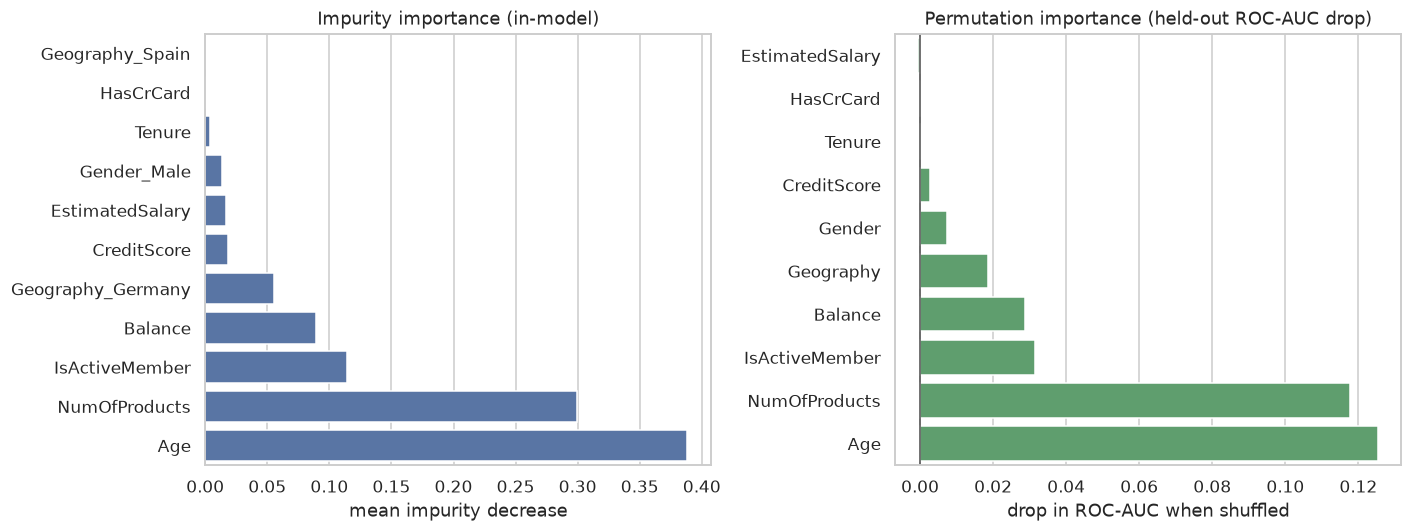

permutation importance, strongest first:
Age                0.1255
NumOfProducts      0.1178
IsActiveMember     0.0316
Balance            0.0289
Geography          0.0187
Gender             0.0073
CreditScore        0.0027
Tenure             0.0002
HasCrCard         -0.0002
EstimatedSalary   -0.0005


In [13]:
feature_names = best_model.named_steps["pre"].get_feature_names_out()
feature_names = [n.split("__", 1)[-1] for n in feature_names]

impurity = pd.Series(best_model.named_steps["clf"].feature_importances_,
                     index=feature_names).sort_values()

perm = permutation_importance(best_model, X_test, y_test, n_repeats=15,
                              random_state=RANDOM_STATE, scoring="roc_auc")
perm_s = pd.Series(perm.importances_mean, index=X_test.columns).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(x=impurity.values, y=impurity.index, ax=axes[0], color="#4c72b0")
axes[0].set(title="Impurity importance (in-model)", xlabel="mean impurity decrease", ylabel="")
sns.barplot(x=perm_s.values, y=perm_s.index, ax=axes[1], color="#55a868")
axes[1].set(title="Permutation importance (held-out ROC-AUC drop)",
            xlabel="drop in ROC-AUC when shuffled", ylabel="")
axes[1].axvline(0, c="0.3", lw=1)
fig.tight_layout()
fig.savefig("results/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("permutation importance, strongest first:")
print(perm_s.sort_values(ascending=False).round(4).to_string())

Both views agree on the top of the list — **Age, NumOfProducts, IsActiveMember, Geography(Germany)
and Balance** carry the prediction, exactly matching the EDA in §3.

They also agree on the bottom, which is the useful part: **`EstimatedSalary`, `HasCrCard` and
`Tenure` contribute essentially nothing.** Permutation importance near zero means shuffling that
column does not hurt the model at all. Salary looks like it should matter and does not — worth
telling the business, because it is probably in their mental model of churn.

Two of these are directly actionable: `IsActiveMember` and `NumOfProducts` are things a bank can
*change*, unlike age or geography.

---
## 8. Save the model

In [14]:
final_model = build(GradientBoostingClassifier(random_state=RANDOM_STATE))
final_model.fit(X, y)          # default weights, per section 6

joblib.dump({
    "pipeline": final_model,
    "threshold": THRESHOLD,     # stored, so it can be retuned without retraining
    "features": list(X.columns),
    "categorical": categorical,
    "numeric": numeric_cols,
}, "models/churn_model.pkl")
print(f"saved -> models/churn_model.pkl  (threshold {THRESHOLD:.2f})")

example = pd.DataFrame([{
    "CreditScore": 600, "Geography": "Germany", "Gender": "Female", "Age": 52,
    "Tenure": 2, "Balance": 120000.0, "NumOfProducts": 1, "HasCrCard": 1,
    "IsActiveMember": 0, "EstimatedSalary": 90000.0,
}])
print(f"\nexample high-risk customer -> churn probability "
      f"{final_model.predict_proba(example)[0, 1]:.1%}")

saved -> models/churn_model.pkl  (threshold 0.28)

example high-risk customer -> churn probability 91.6%


---
## 9. Summary

| | |
|---|---|
| **Best model** | `GradientBoostingClassifier`, default weights, threshold tuned to 0.28 |
| **ROC-AUC** | 0.871 — the metric that actually measures the model, and it is threshold-independent |
| **Recall on churners** | 0.68 at the shipped threshold, vs 0.49 at sklearn's default 0.5 |
| **Why not `class_weight="balanced"`** | It reaches the same operating point with *worse* precision — see §6 |
| **Top features** | Age, NumOfProducts, IsActiveMember, Geography=Germany, Balance |
| **Dead features** | EstimatedSalary, HasCrCard, Tenure — all near-zero permutation importance |

The result the bank should act on is not the AUC. It is that **inactive members and customers
holding 3–4 products churn at extreme rates**, and both are things the bank can intervene on.

**What I would do with more time**

- **Cross-validation instead of one split.** 2,000 test customers, 407 of them churners — one
  20% split gives a point estimate with no error bar.
- **Set the threshold from actual costs.** The dial in §6.2 is only useful once someone supplies the
  cost of a retention offer and the lifetime value of a saved customer.
- **Investigate the 3–4 product cohort directly.** A 100% churn rate on 60 customers is not a
  modelling result, it is a business incident — probably a product being mis-sold or a fee structure
  that punishes holding several accounts.
- **Ask why Germany is double.** Same product, twice the churn, and Spain and France are identical
  to each other. That is a question for the business, and the answer may be worth more than the model.
- **Try HistGradientBoosting / XGBoost** and tune with a randomised search — likely a point or two
  of AUC, far less than the items above are worth.